#EXP 01 - Implement and demonstrate the FIND-S algorithm for finding the most specific hypothesis based on a given set of training data samples.

In [ ]:
def find_s(training_data):

    hypothesis = None

    for example in training_data:
        attributes = example[:-1]
        target = example[-1]

        if target == "Yes":
            if hypothesis is None:
                hypothesis = attributes.copy()
            else:
                for i in range(len(hypothesis)):
                    if hypothesis[i] != attributes[i]:
                        hypothesis[i] = '?'

    return hypothesis


data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

print("Final Hypothesis:", find_s(data))

Final Hypothesis: ['Sunny', 'Warm', '?', 'Strong', '?', '?']


#EXP 02 - For a given set of training data examples stored in a .CSV file, implement and demonstrate the Candidate-Elimination algorithm in python to output a description of the set of all hypotheses consistent with the training examples

In [ ]:
import csv

with open('trainingdata.csv') as csvFile:
    data = list(csv.reader(csvFile))

print("\nTraining Data Set:\n")
for row in data:
    print(row)

num_attributes = len(data[0]) - 1

S = ['0'] * num_attributes
G = ['?'] * num_attributes

print("\nInitial Specific Hypothesis:")
print(S)

print("\nInitial General Hypothesis:")
print(G)

for i in range(1, len(data)):

    if data[i][-1].lower() == "yes":

        for j in range(num_attributes):

            if S[j] == '0':
                S[j] = data[i][j]

            elif S[j] != data[i][j]:
                S[j] = '?'
                G[j] = '?'

    elif data[i][-1].lower() == "no":

        for j in range(num_attributes):

            if S[j] != data[i][j]:
                G[j] = S[j]
            else:
                G[j] = '?'

print("\nFinal Specific Hypothesis:")
print(S)

print("\nFinal General Hypothesis:")
print(G)



Training Data Set:

['Sky', 'AirTemp', 'Humidity', 'Wind', 'Water', 'Forecast', 'EnjoySport']
['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes']
['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes']
['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No']
['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']

Initial Specific Hypothesis:
['0', '0', '0', '0', '0', '0']

Initial General Hypothesis:
['?', '?', '?', '?', '?', '?']

Final Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']

Final General Hypothesis:
['Sunny', 'Warm', '?', '?', '?', '?']


#EXP 03 - Demonstrate the working of the decision tree based ID3 algorithm. Use an appropriate data set for building the decision tree and apply this knowledge to classify a new sample.

In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Dataset
data = {
    'Outlook':[0,0,1,2,2,2,1,0,0,2,0,1,1,2],
    'Temperature':[0,0,0,1,2,2,2,1,2,1,1,1,0,1],
    'Humidity':[0,0,0,0,1,1,1,0,1,1,1,0,1,0],
    'Wind':[0,1,0,0,0,1,1,0,0,0,1,1,0,1]
}

target = [0,0,1,1,1,0,1,0,1,1,1,1,1,0]

# Build feature matrix without pandas
num_rows = len(data['Outlook'])
X = [[
    data['Outlook'][i],
    data['Temperature'][i],
    data['Humidity'][i],
    data['Wind'][i]
] for i in range(num_rows)]

clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, target)

sample = [[0,2,1,0]]
prediction = clf.predict(sample)

if prediction[0] == 1:
    print("Play Tennis = Yes")
else:
    print("Play Tennis = No")

Play Tennis = Yes


#EXP 04 - Build an Artificial Neural Network by implementing the Backpropagation algorithm and test the same using appropriate data sets.

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.01):
        self.lr = learning_rate

        # Initialize weights and biases (He/Xavier-like initialization)
        self.W1 = np.random.randn(input_size, hidden_size) * 0.01
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.01
        self.b2 = np.zeros((1, output_size))

    def _sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def _sigmoid_derivative(self, x):
        # x is already the sigmoid output here to save computation
        return x * (1 - x)

    def _softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True)) # Stability fix
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)

    def forward(self, X):
        # Input to Hidden
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self._sigmoid(self.Z1)

        # Hidden to Output
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self._softmax(self.Z2)
        return self.A2

    def backward(self, X, y, output):
        m = X.shape[0] # Number of samples

        # 1. Output layer error (Categorical Cross-Entropy + Softmax derivative simplifies to this)
        dZ2 = output - y
        dW2 = np.dot(self.A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # 2. Hidden layer error
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self._sigmoid_derivative(self.A1)
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        # 3. Update weights and biases
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=1000):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)

            if epoch % 200 == 0:
                loss = -np.mean(np.sum(y * np.log(output + 1e-8), axis=1))
                print(f"Epoch {epoch:4d} | Loss: {loss:.4f}")

                # 1. Load and preprocess dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encode the target labels (3 classes)
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Scale features for better/faster gradient convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Initialize NN (4 features -> 8 hidden neurons -> 3 output classes)
nn = NeuralNetwork(input_size=4, hidden_size=8, output_size=3, learning_rate=0.1)

# 3. Train the model
print("--- Training Started ---")
nn.train(X_train, y_train, epochs=1000)
print("--- Training Complete ---\n")

# 4. Evaluate on Test Set
predictions = nn.forward(X_test)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

accuracy = np.mean(pred_classes == true_classes) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

--- Training Started ---
Epoch    0 | Loss: 1.0988
Epoch  200 | Loss: 0.9016
Epoch  400 | Loss: 0.4313
Epoch  600 | Loss: 0.3198
Epoch  800 | Loss: 0.2478
--- Training Complete ---

Test Accuracy: 96.67%


# EXP 05 - Write a program for Implementation of K-Nearest Neighbours (K-NN) in Python

In [ ]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        # K-NN just needs to store the training data
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        # 1. Compute Euclidean distances between x and all points in X_train
        # Distance formula: sqrt(sum((x1 - x2)^2))
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

        # 2. Get the indices of the K nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # 3. Extract the labels of those K neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # 4. Return the most common class label (majority vote)
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]


        import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        # K-NN just needs to store the training data
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        # 1. Compute Euclidean distances between x and all points in X_train
        # Distance formula: sqrt(sum((x1 - x2)^2))
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

        # 2. Get the indices of the K nearest neighbors
        k_indices = np.argsort(distances)[:self.k]

        # 3. Extract the labels of those K neighbors
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # 4. Return the most common class label (majority vote)
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# 1. Load and split dataset
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale features (CRITICAL for distance-based algorithms like K-NN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Test our Custom K-NN
custom_knn = KNN(k=5)
custom_knn.fit(X_train, y_train)
custom_preds = custom_knn.predict(X_test)
custom_accuracy = np.mean(custom_preds == y_test) * 100

# 4. Test Scikit-Learn's K-NN
sklearn_knn = KNeighborsClassifier(n_neighbors=5)
sklearn_knn.fit(X_train, y_train)
sklearn_preds = sklearn_knn.predict(X_test)
sklearn_accuracy = np.mean(sklearn_preds == y_test) * 100

# Print results
print(f"--- Results Breakdown ---")
print(f"Custom K-NN Accuracy:   {custom_accuracy:.2f}%")
print(f"Sklearn K-NN Accuracy:  {sklearn_accuracy:.2f}%")

--- Results Breakdown ---
Custom K-NN Accuracy:   94.74%
Sklearn K-NN Accuracy:  94.74%


#EXP 06 - Write a program to implement Naïve Bayes algorithm in python and to display the results using confusion matrix and accuracy.

In [ ]:
import numpy as np

class GaussianNB:
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        # Initialize mean, variance, and priors for each class
        self._mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self._var = np.zeros((n_classes, n_features), dtype=np.float64)
        self._priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self._mean[idx, :] = X_c.mean(axis=0)
            self._var[idx, :] = X_c.var(axis=0) + 1e-9 # Add small epsilon to prevent division by zero
            self._priors[idx] = X_c.shape[0] / float(n_samples)

    def predict(self, X):
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        posteriors = []

        # Calculate posterior probability for each class
        for idx, c in enumerate(self.classes):
            prior = np.log(self._priors[idx])
            posterior = np.sum(np.log(self._pdf(idx, x)))
            posterior = prior + posterior
            posteriors.append(posterior)

        # Return class with the highest posterior probability
        return self.classes[np.argmax(posteriors)]

    def _pdf(self, class_idx, x):
        # Probability Density Function for Gaussian distribution
        mean = self._mean[class_idx]
        var = self._var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

def compute_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred) * 100

def compute_confusion_matrix(y_true, y_pred):
    classes = np.unique(y_true)
    num_classes = len(classes)

    # Map classes to indices if they aren't 0, 1, 2...
    class_to_idx = {ch: i for i, ch in enumerate(classes)}

    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        matrix[class_to_idx[true]][class_to_idx[pred]] += 1

    return matrix, classes

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# 1. Load data
data = load_wine()
X, y = data.data, data.target

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train the Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

# 5. Evaluate Results
accuracy = compute_accuracy(y_test, y_pred)
conf_matrix, class_labels = compute_confusion_matrix(y_test, y_pred)

# Display Results
print(f"=============================")
print(f"      MODEL EVALUATION       ")
print(f"=============================")
print(f"Accuracy: {accuracy:.2f}%\n")

print("Confusion Matrix:")
print("          Predicted")
print("          " + "  ".join([f"C{i}" for i in class_labels]))
print("        " + "-" * (num_spaces := len(class_labels) * 4))

for idx, row in enumerate(conf_matrix):
    print(f"Actual C{class_labels[idx]} | " + "   ".join(map(str, row)))

      MODEL EVALUATION       
Accuracy: 100.00%

Confusion Matrix:
          Predicted
          C0  C1  C2
        ------------
Actual C0 | 19   0   0
Actual C1 | 0   21   0
Actual C2 | 0   0   14


# EXP - 07 - Write a program to implement Logistic Regression (LR) algorithm in python

In [ ]:
import numpy as np

class LogisticRegressionFromScratch:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.lr = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        # Clip z to prevent overflow/underflow warnings in exp
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        num_samples, num_features = X.shape

        # Initialize weights and bias to zeros
        self.weights = np.zeros(num_features)
        self.bias = 0.0

        # Gradient Descent
        for i in range(self.num_iterations):
            # 1. Forward Pass (Linear equation + Sigmoid activation)
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)

            # 2. Compute Gradients
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # 3. Update Parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Print loss every 100 steps
            if i % 100 == 0:
                # Add small epsilon to prevent log(0)
                loss = - (1 / num_samples) * np.sum(y * np.log(y_predicted + 1e-15) + (1 - y) * np.log(1 - y_predicted + 1e-15))
                print(f"Iteration {i:4d} | Loss: {loss:.4f}")

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        # Convert continuous probabilities into binary outcomes (0 or 1)
        probabilities = self.predict_proba(X)
        return np.array([1 if p >= threshold else 0 for p in probabilities])

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic binary dataset
X, y = make_classification(n_samples=500, n_features=5, random_state=42)

# 2. Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale your data (Crucial for gradient descent convergence)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Instantiate and train model
print("--- Training Started ---")
model = LogisticRegressionFromScratch(learning_rate=0.1, num_iterations=500)
model.fit(X_train, y_train)
print("--- Training Completed ---\n")

# 5. Predict on test set
predictions = model.predict(X_test)

# 6. Evaluate accuracy
accuracy = np.mean(predictions == y_test) * 100
print(f"Test Accuracy: {accuracy:.2f}%")
print(f"Final Weights: {model.weights}")
print(f"Final Bias:    {model.bias:.4f}")

--- Training Started ---
Iteration    0 | Loss: 0.6931
Iteration  100 | Loss: 0.3160
Iteration  200 | Loss: 0.2952
Iteration  300 | Loss: 0.2897
Iteration  400 | Loss: 0.2878
--- Training Completed ---

Test Accuracy: 89.00%
Final Weights: [ 1.95087607  0.10502994 -1.25058942  1.05719296  0.17531454]
Final Bias:    0.0282


# EXP 8 - Write a program to implement Linear Regression (LR) algorithm in python


In [ ]:
import numpy as np

class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.lr = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        num_samples, num_features = X.shape

        # 1. Initialize weights (one for each feature) and bias to zero
        self.weights = np.zeros(num_features)
        self.bias = 0.0

        # Gradient Descent Loop
        for i in range(self.num_iterations):
            # 2. Linear prediction formula (y = WX + b)
            y_predicted = np.dot(X, self.weights) + self.bias

            # 3. Compute gradients
            dw = (1 / num_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / num_samples) * np.sum(y_predicted - y)

            # 4. Update parameters using learning rate
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # Print cost evaluation every 100 iterations
            if i % 100 == 0:
                cost = (1 / (2 * num_samples)) * np.sum((y_predicted - y) ** 2)
                print(f"Iteration {i:4d} | Cost (MSE): {cost:.4f}")

    def predict(self, X):
        # Generate predictions using calculated weights and bias
        return np.dot(X, self.weights) + self.bias

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Generate regression dataset (100 samples, 2 features)
X, y = make_regression(n_samples=200, n_features=2, noise=10, random_state=42)

# 2. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize features for smoother gradient descent paths
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Initialize and train the model
print("--- Gradient Descent Updates ---")
model = LinearRegressionFromScratch(learning_rate=0.05, num_iterations=500)
model.fit(X_train, y_train)
print("--------------------------------\n")

# 5. Make predictions
predictions = model.predict(X_test)

# 6. Evaluate Model performance via Mean Squared Error (MSE) from scratch
final_mse = np.mean((predictions - y_test) ** 2)

print(f"--- Final Evaluation Metrics ---")
print(f"Test MSE:       {final_mse:.4f}")
print(f"Final Weights:  {model.weights}")
print(f"Final Bias:     {model.bias:.4f}")

--- Gradient Descent Updates ---
Iteration    0 | Cost (MSE): 1062.9262
Iteration  100 | Cost (MSE): 48.7979
Iteration  200 | Cost (MSE): 48.7209
Iteration  300 | Cost (MSE): 48.7209
Iteration  400 | Cost (MSE): 48.7209
--------------------------------

--- Final Evaluation Metrics ---
Test MSE:       101.6528
Final Weights:  [38.3911012 26.6208154]
Final Bias:     1.5295


# EXP 9 - Compare Linear and Polynomial Regression using Python


--- Linear Regression Metrics ---
MSE: 375.69 | R² Score: 0.62

--- Polynomial Regression (Degree 2) Metrics ---
MSE: 7.58 | R² Score: 0.99



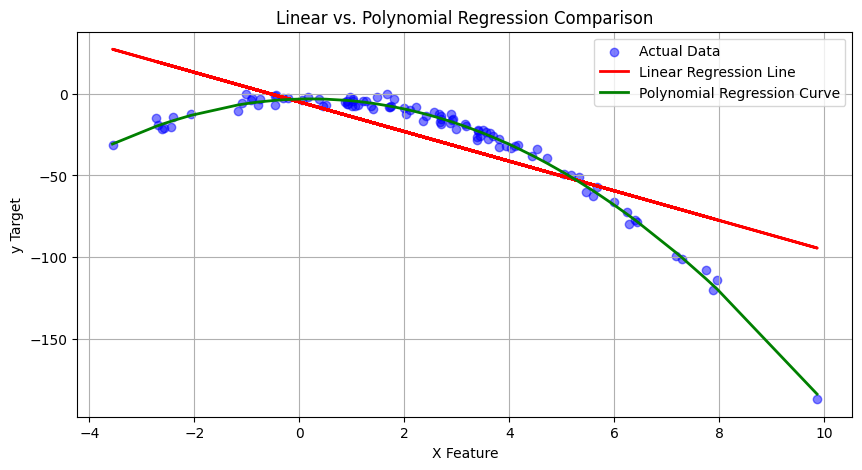

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Non-Linear (Quadratic) Data
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + np.random.normal(-3, 3, 100)

# Reshape for scikit-learn (expects 2D array)
X = X[:, np.newaxis]

# 2. Fit Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X, y)
y_pred_linear = linear_model.predict(X)

# 3. Fit Polynomial Regression Model (Degree = 2)
# Transform X to include X^2 feature: [X] -> [1, X, X^2]
poly_features = PolynomialFeatures(degree=2)
X_poly = poly_features.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

# Sort values for a smooth curve plot line
sort_axis = np.argsort(X.flatten())
X_sorted = X[sort_axis]
y_pred_poly_sorted = poly_model.predict(X_poly)[sort_axis]

# 4. Evaluate Performance Metrics
mse_linear = mean_squared_error(y, y_pred_linear)
r2_linear = r2_score(y, y_pred_linear)

y_pred_poly = poly_model.predict(X_poly)
mse_poly = mean_squared_error(y, y_pred_poly)
r2_poly = r2_score(y, y_pred_poly)

print(f"--- Linear Regression Metrics ---")
print(f"MSE: {mse_linear:.2f} | R² Score: {r2_linear:.2f}\n")

print(f"--- Polynomial Regression (Degree 2) Metrics ---")
print(f"MSE: {mse_poly:.2f} | R² Score: {r2_poly:.2f}\n")

# 5. Plotting the Comparison
plt.figure(figsize=(10, 5))
plt.scatter(X, y, color='blue', alpha=0.5, label='Actual Data')

# Plot Linear Regression Line
plt.plot(X, y_pred_linear, color='red', linewidth=2, label='Linear Regression Line')

# Plot Polynomial Regression Curve
plt.plot(X_sorted, y_pred_poly_sorted, color='green', linewidth=2, label='Polynomial Regression Curve')

plt.title('Linear vs. Polynomial Regression Comparison')
plt.xlabel('X Feature')
plt.ylabel('y Target')
plt.legend()
plt.grid(True)
plt.show()

# EXP 10 - Write a Python Program to Implement Expectation & Maximization Algorithm


Converged early at iteration 41

--- Discovered Parameters ---
Component 1: Estimated Mean = 9.95, Estimated Std = 1.91, Weight = 0.43
Component 2: Estimated Mean = 24.91, Estimated Std = 4.00, Weight = 0.57


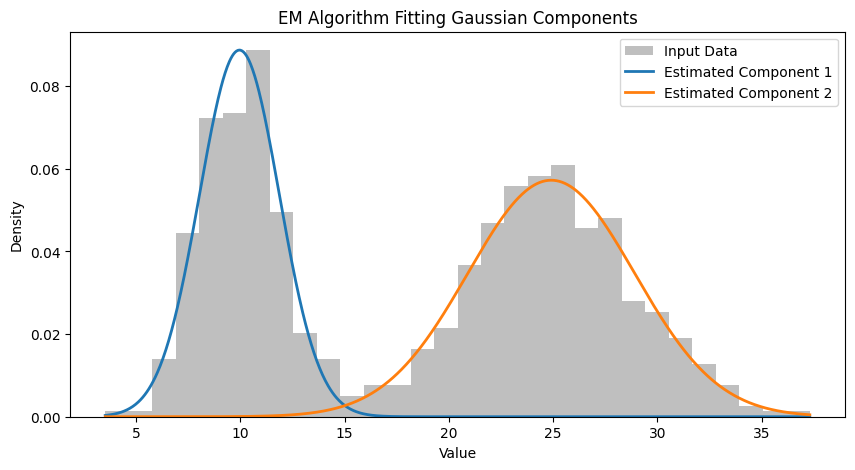

In [ ]:
import numpy as np
from scipy.stats import norm

class EM_GaussianMixture1D:
    def __init__(self, n_components=2, max_iter=100, tol=1e-4):
        self.K = n_components
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X):
        # X is a 1D array of data points
        self.X = X
        n_samples = X.shape[0]

        # 1. Initialize parameters randomly/heuristically
        self.pi = np.ones(self.K) / self.K                  # Mixing weights
        self.mu = np.random.choice(X, self.K)               # Means
        self.sigma = np.ones(self.K) * np.std(X)            # Standard deviations

        log_likelihood_old = 0

        for iteration in range(self.max_iter):
            # -----------------
            # EXPECTATION (E) STEP
            # -----------------
            # Compute likelihood of each data point under each Gaussian component
            likelihood = np.zeros((n_samples, self.K))
            for k in range(self.K):
                likelihood[:, k] = norm.pdf(self.X, self.mu[k], self.sigma[k])

            # Compute responsibilities (gamma) using Bayes' theorem
            numerator = likelihood * self.pi
            denominator = np.sum(numerator, axis=1, keepdims=True)
            gamma = numerator / denominator  # Shape: (n_samples, K)

            # -----------------
            # MAXIMIZATION (M) STEP
            # -----------------
            # Total weight assigned to each component
            N_k = np.sum(gamma, axis=0)

            # Update weights, means, and standard deviations
            self.pi = N_k / n_samples

            for k in range(self.K):
                self.mu[k] = np.sum(gamma[:, k] * self.X) / N_k[k]

                # Variance calculation: sum(gamma * (x - mu)^2) / N_k
                variance = np.sum(gamma[:, k] * (self.X - self.mu[k])**2) / N_k[k]
                self.sigma[k] = np.sqrt(variance) + 1e-6 # Avoid zero variance

            # -----------------
            # Check Convergence
            # -----------------
            log_likelihood = np.sum(np.log(denominator))
            if np.abs(log_likelihood - log_likelihood_old) < self.tol:
                print(f"Converged early at iteration {iteration}")
                break
            log_likelihood_old = log_likelihood

    def predict_proba(self, X):
        # Outputs soft clustering probabilities
        likelihood = np.zeros((X.shape[0], self.K))
        for k in range(self.K):
            likelihood[:, k] = norm.pdf(X, self.mu[k], self.sigma[k])
        numerator = likelihood * self.pi
        return numerator / np.sum(numerator, axis=1, keepdims=True)

    def predict(self, X):
        # Outputs hard cluster assignments
        return np.argmax(self.predict_proba(X), axis=1)

import matplotlib.pyplot as plt

# 1. Generate Synthetic Mixture Data
np.random.seed(42)
component1 = np.random.normal(loc=10, scale=2, size=300)
component2 = np.random.normal(loc=25, scale=4, size=400)
data = np.concatenate([component1, component2])

# 2. Fit the EM model
gmm = EM_GaussianMixture1D(n_components=2, max_iter=200)
gmm.fit(data)

# Print discovered parameters vs actual parameters
print("\n--- Discovered Parameters ---")
for k in range(gmm.K):
    print(f"Component {k+1}: Estimated Mean = {gmm.mu[k]:.2f}, Estimated Std = {gmm.sigma[k]:.2f}, Weight = {gmm.pi[k]:.2f}")

# 3. Plotting Results
plt.figure(figsize=(10, 5))
# Plot histogram of actual data
plt.hist(data, bins=30, density=True, alpha=0.5, color='gray', label='Input Data')

# Plot estimated densities
x_axis = np.linspace(min(data), max(data), 1000)
for k in range(gmm.K):
    y_axis = gmm.pi[k] * norm.pdf(x_axis, gmm.mu[k], gmm.sigma[k])
    plt.plot(x_axis, y_axis, label=f'Estimated Component {k+1}', linewidth=2)

plt.title('EM Algorithm Fitting Gaussian Components')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()

# EXP 11 - Write a program for the task of Credit Score Classification


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000, n_features=5, n_informative=3, n_redundant=1, n_repeated=1, n_classes=2,
                           n_clusters_per_class=1, weights=[0.8, 0.2], flip_y=0.05, random_state=42)

feature_names = ['Income', 'Debt_Ratio', 'Credit_Score', 'Loan_Amount', 'Employment_Length']
df = pd.DataFrame(X, columns=feature_names)
df['Credit_Risk'] = y

print("Sample of the synthetic credit dataset:")
print(df.head())
print(f"\nNumber of High Risk (1): {df['Credit_Risk'].sum()}")
print(f"Number of Low Risk (0): {len(df) - df['Credit_Risk'].sum()}\n")

X = df[feature_names]
y = df['Credit_Risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, solver='liblinear')
print("Training the Logistic Regression model...")
model.fit(X_train_scaled, y_train)
print("Model training complete.\n")

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Probability of being 'High Risk'

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Accuracy: {accuracy:.4f}\n")

print("Confusion Matrix:")
print(conf_matrix)
print("  (True Neg | False Pos)")
print("  (False Neg | True Pos)\n")

print("Classification Report:")
print(class_report)

print("--- Predicting a new sample ---")

new_applicant = np.array([[50000, 0.3, 720, 15000, 5]])

new_applicant_scaled = scaler.transform(new_applicant)

new_pred = model.predict(new_applicant_scaled)
new_pred_proba = model.predict_proba(new_applicant_scaled)[:, 1]

print(f"New Applicant Features: {new_applicant[0]}")
print(f"Predicted Credit Risk (0=Low, 1=High): {new_pred[0]}")
print(f"Probability of being High Risk: {new_pred_proba[0]:.4f}")

if new_pred[0] == 0:
    print("Conclusion: This applicant is predicted to be low credit risk.")
else:
    print("Conclusion: This applicant is predicted to be high credit risk.")

Sample of the synthetic credit dataset:
     Income  Debt_Ratio  Credit_Score  Loan_Amount  Employment_Length  \
0  0.801244   -1.342472      1.877893    -1.189583          -1.189583   
1  0.221728   -0.044606      1.612851    -1.350174          -1.350174   
2  0.949966   -2.393128      1.455677    -0.910851          -0.910851   
3 -0.177262    0.450735      0.416865    -0.550888          -0.550888   
4  0.046803    1.084493      1.640934    -1.227536          -1.227536   

   Credit_Risk  
0            0  
1            0  
2            0  
3            1  
4            1  

Number of High Risk (1): 208
Number of Low Risk (0): 792

Training set size: 700 samples
Testing set size: 300 samples

Training the Logistic Regression model...
Model training complete.

--- Model Evaluation ---
Accuracy: 0.9133

Confusion Matrix:
[[223  15]
 [ 11  51]]
  (True Neg | False Pos)
  (False Neg | True Pos)

Classification Report:
              precision    recall  f1-score   support

           0     

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# EXP 12 - Implement Iris Flower Classification using KNN

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Scale features (important for distance-based algorithms like K-NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train a K-Nearest Neighbors classifier
# Let's choose k=5, a common starting point.
knn_model = KNeighborsClassifier(n_neighbors=5)
print("Training KNN model...")
knn_model.fit(X_train_scaled, y_train)
print("KNN model training complete.\n")

# 5. Make predictions on the test set
y_pred = knn_model.predict(X_test_scaled)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"--- Iris Classification with KNN ---")
print(f"Accuracy: {accuracy:.4f}\n")

print("Confusion Matrix:")
print(conf_matrix)
print("  (Rows: Actual Classes, Columns: Predicted Classes)\n")

print("Classification Report:")
print(class_report)

# Example of predicting a new sample
print("--- Predicting a new Iris flower ---")
# Let's create a hypothetical new flower's data (sepal length, sepal width, petal length, petal width)
# For example, a flower with characteristics similar to 'setosa'
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale the new flower's data using the *same* scaler fitted on training data
new_flower_scaled = scaler.transform(new_flower)

new_pred = knn_model.predict(new_flower_scaled)
new_pred_proba = knn_model.predict_proba(new_flower_scaled)

print(f"New Flower Features: {new_flower[0]}")
print(f"Predicted Class: {iris.target_names[new_pred[0]]}")
print(f"Probabilities for each class: {new_pred_proba[0].round(2)}")
print(f"Conclusion: This flower is predicted to be a {iris.target_names[new_pred[0]]}.")

Training KNN model...
KNN model training complete.

--- Iris Classification with KNN ---
Accuracy: 0.9111

Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  4 11]]
  (Rows: Actual Classes, Columns: Predicted Classes)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.79      1.00      0.88        15
   virginica       1.00      0.73      0.85        15

    accuracy                           0.91        45
   macro avg       0.93      0.91      0.91        45
weighted avg       0.93      0.91      0.91        45

--- Predicting a new Iris flower ---
New Flower Features: [5.1 3.5 1.4 0.2]
Predicted Class: setosa
Probabilities for each class: [1. 0. 0.]
Conclusion: This flower is predicted to be a setosa.


# EXP 13 - Implement Car Price Prediction Model using Python


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Generate a Synthetic Dataset for Car Price Prediction
np.random.seed(42)
n_samples = 1000

data = {
    'Year': np.random.randint(2005, 2023, n_samples),
    'Mileage': np.random.randint(10000, 150000, n_samples),
    'Engine_Size': np.round(np.random.uniform(1.0, 4.0, n_samples), 1),
    'Brand': np.random.choice(['Toyota', 'Honda', 'Ford', 'BMW', 'Mercedes'], n_samples)
}

df = pd.DataFrame(data)

# Introduce some correlation with price
# Base price depends on brand, year, mileage, and engine size
df['Price'] = (
    30000 # Base price
    - (2023 - df['Year']) * 1000 # Newer cars are more expensive
    - df['Mileage'] * 0.1 # Higher mileage reduces price
    + df['Engine_Size'] * 5000 # Larger engine size increases price
    + np.where(df['Brand'] == 'BMW', 15000,
               np.where(df['Brand'] == 'Mercedes', 18000,
                        np.where(df['Brand'] == 'Toyota', 5000,
                                 np.where(df['Brand'] == 'Honda', 6000, 0)))) # Brand impact
    + np.random.normal(0, 3000, n_samples) # Add some random noise
)

# Ensure prices are not negative
df['Price'] = df['Price'].apply(lambda x: max(1000, x))

print("Sample of the synthetic car dataset:")
print(df.head())
print(f"\nDataset size: {len(df)} samples")

# 2. Define Features (X) and Target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# 3. Preprocessing: One-hot encode 'Brand' and scale numerical features
# Identify categorical and numerical features
categorical_features = ['Brand']
numerical_features = ['Year', 'Mileage', 'Engine_Size']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Create a pipeline with preprocessor and RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 5. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples\n")

# 6. Train the model
print("Training the Car Price Prediction Model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.\n")

# 7. Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# 8. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared (R²): {r2:.4f}\n")

# 9. Example of predicting a new car's price
print("--- Predicting a new car's price ---")
new_car_data = pd.DataFrame([{
    'Year': 2022,
    'Mileage': 25000,
    'Engine_Size': 2.0,
    'Brand': 'BMW'
}])

predicted_price = model_pipeline.predict(new_car_data)

print(f"New Car Details:\n{new_car_data}")
print(f"Predicted Price: ${predicted_price[0]:,.2f}")


Sample of the synthetic car dataset:
   Year  Mileage  Engine_Size     Brand         Price
0  2011   109608          2.9      Ford  20952.164323
1  2019    70774          3.3       BMW  54858.770828
2  2015    33752          1.7    Toyota  30939.913411
3  2012    65029          1.4  Mercedes  39223.116592
4  2011   140282          3.0  Mercedes  39153.040061

Dataset size: 1000 samples

Training set size: 800 samples
Testing set size: 200 samples

Training the Car Price Prediction Model...
Model training complete.

--- Model Evaluation ---
Mean Absolute Error (MAE): $2,576.68
R-squared (R²): 0.9076

--- Predicting a new car's price ---
New Car Details:
   Year  Mileage  Engine_Size Brand
0  2022    25000          2.0   BMW
Predicted Price: $45,609.99


# EXP 14 - Implement House Price Prediction Model using Python

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Generate a Synthetic Dataset for House Price Prediction
np.random.seed(42)
n_samples = 1000

data = {
    'Size_sqft': np.random.randint(800, 5000, n_samples),
    'Bedrooms': np.random.randint(1, 6, n_samples),
    'Bathrooms': np.random.choice([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0], n_samples),
    'Year_Built': np.random.randint(1980, 2023, n_samples),
    'Location': np.random.choice(['Suburb_A', 'City_Center', 'Rural_Area', 'Suburb_B'], n_samples)
}

df = pd.DataFrame(data)

# Introduce some correlation with price
# Base price depends on size, bedrooms, bathrooms, year built, and location
df['Price'] = (
    100000 # Base price
    + df['Size_sqft'] * 150 # Price per square foot
    + df['Bedrooms'] * 15000
    + df['Bathrooms'] * 20000
    + (2023 - df['Year_Built']) * -2000 # Newer houses are more expensive
    + np.where(df['Location'] == 'City_Center', 150000,
               np.where(df['Location'] == 'Suburb_A', 75000,
                        np.where(df['Location'] == 'Suburb_B', 50000, 0))) # Location impact
    + np.random.normal(0, 25000, n_samples) # Add some random noise
)

# Ensure prices are not negative
df['Price'] = df['Price'].apply(lambda x: max(50000, x))

print("Sample of the synthetic house dataset:")
print(df.head())
print(f"\nDataset size: {len(df)} samples")

# 2. Define Features (X) and Target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# 3. Preprocessing: One-hot encode 'Location' and scale numerical features
# Identify categorical and numerical features
categorical_features = ['Location']
numerical_features = ['Size_sqft', 'Bedrooms', 'Bathrooms', 'Year_Built']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Create a pipeline with preprocessor and RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 5. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples\n")

# 6. Train the model
print("Training the House Price Prediction Model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.\n")

# 7. Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# 8. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared (R²): {r2:.4f}\n")

# 9. Example of predicting a new house's price
print("--- Predicting a new house's price ---")
new_house_data = pd.DataFrame([{
    'Size_sqft': 2500,
    'Bedrooms': 4,
    'Bathrooms': 2.5,
    'Year_Built': 2010,
    'Location': 'Suburb_A'
}])

predicted_price = model_pipeline.predict(new_house_data)

print(f"New House Details:\n{new_house_data}")
print(f"Predicted Price: ${predicted_price[0]:,.2f}")

Sample of the synthetic house dataset:
   Size_sqft  Bedrooms  Bathrooms  Year_Built  Location          Price
0       1660         2        3.5        2012  Suburb_A  484152.725314
1       4572         5        2.5        1991  Suburb_B  939054.440834
2       3892         1        1.5        1994  Suburb_A  768934.952270
3       1266         1        2.5        2020  Suburb_A  424694.539204
4       4244         1        2.5        2018  Suburb_A  909827.869202

Dataset size: 1000 samples

Training set size: 800 samples
Testing set size: 200 samples

Training the House Price Prediction Model...
Model training complete.

--- Model Evaluation ---
Mean Absolute Error (MAE): $29,192.00
R-squared (R²): 0.9633

--- Predicting a new house's price ---
New House Details:
   Size_sqft  Bedrooms  Bathrooms  Year_Built  Location
0       2500         4        2.5        2010  Suburb_A
Predicted Price: $616,157.46


# EXP 15 - Implement Iris Flower Classification using Naive Bayes Classifier


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Feature Scaling (optional for Gaussian Naive Bayes, but good practice for consistency and other models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train a Gaussian Naive Bayes classifier
nb_model = GaussianNB()
print("Training Gaussian Naive Bayes model...")
nb_model.fit(X_train_scaled, y_train)
print("Model training complete.\n")

# 5. Make predictions on the test set
y_pred = nb_model.predict(X_test_scaled)
y_pred_proba = nb_model.predict_proba(X_test_scaled) # Probabilities for each class

# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=iris.target_names)

print(f"--- Iris Classification with Gaussian Naive Bayes ---")
print(f"Accuracy: {accuracy:.4f}\n")

print("Confusion Matrix:")
print(conf_matrix)
print("  (Rows: Actual Classes, Columns: Predicted Classes)\n")

print("Classification Report:")
print(class_report)

# Example of predicting a new sample
print("--- Predicting a new Iris flower ---")
# Let's create a hypothetical new flower's data (sepal length, sepal width, petal length, petal width)
# For example, a flower with characteristics similar to 'setosa'
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale the new flower's data using the *same* scaler fitted on training data
new_flower_scaled = scaler.transform(new_flower)

new_pred = nb_model.predict(new_flower_scaled)
new_pred_proba = nb_model.predict_proba(new_flower_scaled)

print(f"New Flower Features: {new_flower[0]}")
print(f"Predicted Class: {iris.target_names[new_pred[0]]}")
print(f"Probabilities for each class: {new_pred_proba[0].round(2)}")
print(f"Conclusion: This flower is predicted to be a {iris.target_names[new_pred[0]]}.")

Training Gaussian Naive Bayes model...
Model training complete.

--- Iris Classification with Gaussian Naive Bayes ---
Accuracy: 0.9111

Confusion Matrix:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]
  (Rows: Actual Classes, Columns: Predicted Classes)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45

--- Predicting a new Iris flower ---
New Flower Features: [5.1 3.5 1.4 0.2]
Predicted Class: setosa
Probabilities for each class: [1. 0. 0.]
Conclusion: This flower is predicted to be a setosa.


# EXP 16 - Compare different Classification Algorithms

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

print("--- Classification Algorithms Comparison on Iris Dataset ---\n")

# 2. Split the dataset into training and testing sets
# Using stratify=y to ensure equal proportion of classes in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 3. Feature Scaling (important for distance-based and gradient-descent based algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store models and their accuracies
models = {
    "K-Nearest Neighbors (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets
}

results = {}

# 4. Train and Evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    # Naive Bayes doesn't strictly require scaled data but it doesn't hurt
    if name == "Gaussian Naive Bayes":
        model.fit(X_train, y_train) # Use unscaled data for Naive Bayes for simplicity, though scaled is also fine.
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} training complete. Accuracy: {accuracy:.4f}\n")

# 5. Present Comparison
print("--- Comparison of Classifier Performance ---")
performance_df = pd.DataFrame(results.items(), columns=['Classifier', 'Accuracy'])
performance_df = performance_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print(performance_df.to_string(index=False))


--- Classification Algorithms Comparison on Iris Dataset ---

Training K-Nearest Neighbors (k=5)...
K-Nearest Neighbors (k=5) training complete. Accuracy: 0.9111

Training Gaussian Naive Bayes...
Gaussian Naive Bayes training complete. Accuracy: 0.9111

Training Logistic Regression...
Logistic Regression training complete. Accuracy: 0.8000

--- Comparison of Classifier Performance ---
               Classifier  Accuracy
K-Nearest Neighbors (k=5)  0.911111
     Gaussian Naive Bayes  0.911111
      Logistic Regression  0.800000


# EXP 17 - Implement Mobile Price Prediction using appropriate machine learning algorithm

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Generate a Synthetic Dataset for Mobile Price Prediction
np.random.seed(42)
n_samples = 1000

data = {
    'Brand': np.random.choice(['Samsung', 'Apple', 'Xiaomi', 'OnePlus', 'Google'], n_samples),
    'RAM_GB': np.random.choice([4, 6, 8, 12, 16], n_samples),
    'Storage_GB': np.random.choice([64, 128, 256, 512], n_samples),
    'Screen_Size_inch': np.round(np.random.uniform(5.5, 7.0, n_samples), 1),
    'Camera_MP': np.random.randint(12, 108, n_samples),
    'Battery_mAh': np.random.randint(3000, 6000, n_samples),
    'Release_Year': np.random.randint(2020, 2024, n_samples)
}

df = pd.DataFrame(data)

# Introduce some correlation with price
df['Price'] = (
    300 # Base price
    + df['RAM_GB'] * 25 # RAM impacts price
    + df['Storage_GB'] * 1.5 # Storage impacts price
    + df['Screen_Size_inch'] * 50 # Screen size impacts price
    + df['Camera_MP'] * 2 # Camera megapixels impact price
    + df['Battery_mAh'] * 0.05 # Battery size impacts price
    + (2024 - df['Release_Year']) * -100 # Newer phones are more expensive
    + np.where(df['Brand'] == 'Apple', 400,
               np.where(df['Brand'] == 'Samsung', 250,
                        np.where(df['Brand'] == 'Google', 200, 0))) # Brand impact
    + np.random.normal(0, 75, n_samples) # Add some random noise
)

# Ensure prices are not negative
df['Price'] = df['Price'].apply(lambda x: max(100, x))

print("Sample of the synthetic mobile phone dataset:")
print(df.head())
print(f"\nDataset size: {len(df)} samples")

# 2. Define Features (X) and Target (y)
X = df.drop('Price', axis=1)
y = df['Price']

# 3. Preprocessing: One-hot encode 'Brand' and scale numerical features
categorical_features = ['Brand']
numerical_features = ['RAM_GB', 'Storage_GB', 'Screen_Size_inch', 'Camera_MP', 'Battery_mAh', 'Release_Year']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Create a pipeline with preprocessor and RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 5. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples\n")

# 6. Train the model
print("Training the Mobile Price Prediction Model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.\n")

# 7. Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# 8. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared (R²): {r2:.4f}\n")

# 9. Example of predicting a new mobile phone's price
print("--- Predicting a new mobile phone's price ---")
new_mobile_data = pd.DataFrame([{
    'Brand': 'Apple',
    'RAM_GB': 8,
    'Storage_GB': 256,
    'Screen_Size_inch': 6.1,
    'Camera_MP': 48,
    'Battery_mAh': 3200,
    'Release_Year': 2023
}])

predicted_price = model_pipeline.predict(new_mobile_data)

print(f"New Mobile Phone Details:\n{new_mobile_data}")
print(f"Predicted Price: ${predicted_price[0]:,.2f}")


Sample of the synthetic mobile phone dataset:
     Brand  RAM_GB  Storage_GB  Screen_Size_inch  Camera_MP  Battery_mAh  \
0  OnePlus      12         512               7.0         21         3151   
1   Google      12         256               6.7         64         4028   
2   Xiaomi      12         512               5.5         90         4218   
3   Google      12         256               5.6         70         4977   
4   Google      16         128               6.2         33         5511   

   Release_Year        Price  
0          2020  1462.097144  
1          2023  1837.792450  
2          2021  1805.151187  
3          2020  1471.075354  
4          2021  1328.597458  

Dataset size: 1000 samples

Training set size: 800 samples
Testing set size: 200 samples

Training the Mobile Price Prediction Model...
Model training complete.

--- Model Evaluation ---
Mean Absolute Error (MAE): $81.26
R-squared (R²): 0.9120

--- Predicting a new mobile phone's price ---
New Mobile Phone De

# EXP 18 - Implement Perceptron based IRIS classification

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Implement Perceptron from scratch
class Perceptron:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.activation_func = self._unit_step_func
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Convert labels to -1 or 1 for Perceptron
        y_ = np.where(y == 0, -1, 1)

        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)

                # Perceptron update rule
                update = self.lr * (y_[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation_func(linear_output)
        # Convert back to original labels if needed (0 or 1)
        return np.where(y_predicted == -1, 0, 1)

    def _unit_step_func(self, x):
        return np.where(x >= 0, 1, -1)


# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# For Perceptron, we'll perform binary classification.
# Let's classify Iris-setosa (0) vs. Iris-versicolor (1).
# We'll filter out Iris-virginica (2).

# Select only the first two classes (0 and 1)
X_binary = X[y != 2]
y_binary = y[y != 2]

print("--- Perceptron-based IRIS Classification (Binary) ---\n")

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

# 3. Scale features (important for Perceptron convergence)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the Perceptron model
perceptron_model = Perceptron(learning_rate=0.01, n_iterations=100)
print("Training Perceptron model...")
perceptron_model.fit(X_train_scaled, y_train)
print("Perceptron model training complete.\n")

# 5. Make predictions on the test set
y_pred = perceptron_model.predict(X_test_scaled)

# 6. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Accuracy: {accuracy:.4f}")

# Example of predicting a new sample
print("\n--- Predicting a new Iris flower ---")
# Example of an Iris-setosa (first two features)
new_flower_setosa = np.array([[5.1, 3.5, 1.4, 0.2]])
# Example of an Iris-versicolor (first two features)
new_flower_versicolor = np.array([[5.9, 3.2, 4.8, 1.8]])

# Scale the new flower's data using the *same* scaler fitted on training data
new_flower_setosa_scaled = scaler.transform(new_flower_setosa)
new_flower_versicolor_scaled = scaler.transform(new_flower_versicolor)

pred_setosa = perceptron_model.predict(new_flower_setosa_scaled)
pred_versicolor = perceptron_model.predict(new_flower_versicolor_scaled)

# Map back to original target names for clarity
predicted_class_setosa = iris.target_names[pred_setosa[0]]
predicted_class_versicolor = iris.target_names[pred_versicolor[0]]

print(f"New Setosa-like Flower Features: {new_flower_setosa[0]}")
print(f"Predicted Class: {predicted_class_setosa}")

print(f"\nNew Versicolor-like Flower Features: {new_flower_versicolor[0]}")
print(f"Predicted Class: {predicted_class_versicolor}")


--- Perceptron-based IRIS Classification (Binary) ---

Training Perceptron model...
Perceptron model training complete.

--- Model Evaluation ---
Accuracy: 1.0000

--- Predicting a new Iris flower ---
New Setosa-like Flower Features: [5.1 3.5 1.4 0.2]
Predicted Class: setosa

New Versicolor-like Flower Features: [5.9 3.2 4.8 1.8]
Predicted Class: versicolor


# EXP 19 - Implementation of Naive Bayes classification for Bank Loan prediction

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_classification

# 1. Generate a Synthetic Dataset for Bank Loan Prediction
# Let's create a dataset with features relevant to loan approval
np.random.seed(42)
n_samples = 1000

# Features: Income, Credit_Score, Loan_Amount, Employment_Duration
# Target: Loan_Approved (0=No, 1=Yes)
X, y = make_classification(
    n_samples=n_samples,
    n_features=4,
    n_informative=3,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    weights=[0.6, 0.4], # Roughly 60% rejected, 40% approved
    flip_y=0.05,
    random_state=42
)

# Map features to more interpretable values
df_features = pd.DataFrame(X, columns=['Income', 'Credit_Score', 'Loan_Amount', 'Employment_Duration'])

# Adjust ranges to be more realistic for loan prediction
df_features['Income'] = np.exp(df_features['Income'] * 0.5 + 8) # e.g., $3000 to $100000+
df_features['Credit_Score'] = df_features['Credit_Score'] * 100 + 650 # e.g., 550 to 800+
df_features['Loan_Amount'] = np.exp(df_features['Loan_Amount'] * 0.7 + 9) # e.g., $5000 to $500000+
df_features['Employment_Duration'] = np.abs(df_features['Employment_Duration'] * 2 + 5) # e.g., 1 to 20 years

# Ensure non-negativity and reasonable ranges
df_features['Income'] = df_features['Income'].apply(lambda x: max(30000, x))
df_features['Credit_Score'] = df_features['Credit_Score'].apply(lambda x: min(850, max(300, x)))
df_features['Loan_Amount'] = df_features['Loan_Amount'].apply(lambda x: max(10000, x))
df_features['Employment_Duration'] = df_features['Employment_Duration'].apply(lambda x: max(0.5, x))

df = df_features
df['Loan_Approved'] = y

print("--- Synthetic Bank Loan Dataset Sample ---")
print(df.head())
print(f"\nDataset size: {len(df)} samples")
print(f"Loan Approved (1): {df['Loan_Approved'].sum()} samples")
print(f"Loan Rejected (0): {len(df) - df['Loan_Approved'].sum()} samples\n")

# 2. Define Features (X) and Target (y)
X = df.drop('Loan_Approved', axis=1)
y = df['Loan_Approved']

# 3. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples\n")

# 4. Feature Scaling (important for many ML algorithms, often beneficial for Naive Bayes as well)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Initialize and train a Gaussian Naive Bayes classifier
nb_model = GaussianNB()
print("Training Gaussian Naive Bayes model for Bank Loan Prediction...")
nb_model.fit(X_train_scaled, y_train)
print("Model training complete.\n")

# 6. Make predictions on the test set
y_pred = nb_model.predict(X_test_scaled)
y_pred_proba = nb_model.predict_proba(X_test_scaled) # Probabilities for each class

# 7. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred, target_names=['Rejected', 'Approved'])

print(f"--- Model Evaluation: Naive Bayes for Bank Loan Prediction ---")
print(f"Accuracy: {accuracy:.4f}\n")

print("Confusion Matrix:")
print(conf_matrix)
print("  (True Rejected | False Approved)")
print("  (False Rejected | True Approved)\n")

print("Classification Report:")
print(class_report)

# 8. Example of predicting a new loan applicant
print("--- Predicting a new loan applicant ---")
# Hypothetical new applicant data
new_applicant = pd.DataFrame([{
    'Income': 75000,           # High income
    'Credit_Score': 720,      # Good credit score
    'Loan_Amount': 150000,    # Moderate loan amount
    'Employment_Duration': 10 # Long employment duration
}])

# Scale the new applicant's data using the *same* scaler fitted on training data
new_applicant_scaled = scaler.transform(new_applicant)

new_pred = nb_model.predict(new_applicant_scaled)
new_pred_proba = nb_model.predict_proba(new_applicant_scaled)

print(f"New Applicant Details:\n{new_applicant}")
print(f"Predicted Loan Status (0=Rejected, 1=Approved): {new_pred[0]}")
print(f"Probability of Loan Rejected: {new_pred_proba[0][0]:.4f}")
print(f"Probability of Loan Approved: {new_pred_proba[0][1]:.4f}")

if new_pred[0] == 1:
    print("Conclusion: This loan is predicted to be Approved.")
else:
    print("Conclusion: This loan is predicted to be Rejected.")


--- Synthetic Bank Loan Dataset Sample ---
   Income  Credit_Score   Loan_Amount  Employment_Duration  Loan_Approved
0   30000    756.357201  17713.238733             1.328593              1
1   30000    601.845980  10000.000000             3.674224              0
2   30000    509.383321  11780.155698             3.541003              0
3   30000    685.573437  25986.775914             1.838879              0
4   30000    658.428893  22519.688786             2.305491              0

Dataset size: 1000 samples
Loan Approved (1): 410 samples
Loan Rejected (0): 590 samples

Training set size: 700 samples
Testing set size: 300 samples

Training Gaussian Naive Bayes model for Bank Loan Prediction...
Model training complete.

--- Model Evaluation: Naive Bayes for Bank Loan Prediction ---
Accuracy: 0.9000

Confusion Matrix:
[[161  16]
 [ 14 109]]
  (True Rejected | False Approved)
  (False Rejected | True Approved)

Classification Report:
              precision    recall  f1-score   support


# EXP 20 - Implement Future Sales Prediction using a suitable machine learning algorithm

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Generate a Synthetic Dataset for Future Sales Prediction
np.random.seed(42)
n_samples = 1000

data = {
    'Month': np.random.choice(pd.date_range(start='2022-01-01', periods=12, freq='MS').strftime('%B'), n_samples),
    'Advertising_Spend': np.random.randint(5000, 50000, n_samples),
    'Promotional_Campaign': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]), # 0=No, 1=Yes
    'Competitor_Activity_Index': np.random.uniform(0.1, 1.0, n_samples),
    'Economic_Index': np.random.uniform(0.8, 1.2, n_samples)
}

df = pd.DataFrame(data)

# Introduce some correlation with sales
def calculate_sales(row):
    base_sales = 10000
    sales = base_sales

    # Advertising has a positive impact
    sales += row['Advertising_Spend'] * 0.5

    # Promotional campaigns boost sales
    if row['Promotional_Campaign'] == 1:
        sales += 0.2 * base_sales

    # Competitor activity might reduce sales
    sales -= row['Competitor_Activity_Index'] * 5000

    # Economic index influences sales
    sales *= row['Economic_Index']

    # Seasonal effects
    if row['Month'] in ['November', 'December']:
        sales *= 1.3 # Holiday season boost
    elif row['Month'] in ['January', 'February']:
        sales *= 0.8 # Post-holiday dip

    # Add random noise
    sales += np.random.normal(0, 5000)
    return max(1000, sales) # Ensure sales are not too low

df['Sales'] = df.apply(calculate_sales, axis=1)

print("Sample of the synthetic sales dataset:")
print(df.head())
print(f"\nDataset size: {len(df)} samples\n")

# 2. Define Features (X) and Target (y)
X = df.drop('Sales', axis=1)
y = df['Sales']

# 3. Preprocessing: One-hot encode categorical features and scale numerical features
categorical_features = ['Month']
numerical_features = ['Advertising_Spend', 'Promotional_Campaign', 'Competitor_Activity_Index', 'Economic_Index']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 4. Create a pipeline with preprocessor and RandomForestRegressor
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 5. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples\n")

# 6. Train the model
print("Training the Future Sales Prediction Model...")
model_pipeline.fit(X_train, y_train)
print("Model training complete.\n")

# 7. Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# 8. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"R-squared (R²): {r2:.4f}\n")

# 9. Example of predicting future sales
print("--- Predicting Future Sales ---")
new_sales_data = pd.DataFrame([{
    'Month': 'October', # Example for October
    'Advertising_Spend': 35000,
    'Promotional_Campaign': 1,
    'Competitor_Activity_Index': 0.6,
    'Economic_Index': 1.1
}])

predicted_sales = model_pipeline.predict(new_sales_data)

print(f"Future Scenario Details:\n{new_sales_data}")
print(f"Predicted Sales: ${predicted_sales[0]:,.2f}")


Sample of the synthetic sales dataset:
      Month  Advertising_Spend  Promotional_Campaign  \
0      July              11767                     0   
1     April              32139                     0   
2  November              16613                     0   
3    August              15589                     1   
4       May              18918                     0   

   Competitor_Activity_Index  Economic_Index         Sales  
0                   0.194733        0.921612  18592.067383  
1                   0.250624        0.927242  16986.107441  
2                   0.974823        1.184464  26420.923466  
3                   0.305638        1.156684  17485.746651  
4                   0.979707        1.139672  25501.832420  

Dataset size: 1000 samples

Training set size: 800 samples
Testing set size: 200 samples

Training the Future Sales Prediction Model...
Model training complete.

--- Model Evaluation ---
Mean Absolute Error (MAE): $4,380.57
R-squared (R²): 0.6235

--- Predi